# CASE BS CHASH - ESTÁGIO DADOS/BI

## Imports

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk import tokenize
import unidecode

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

In [61]:
df = pd.read_excel('data/Case - Base de Dados.xlsx',sheet_name='Base')

In [62]:
df.head()

,Id Comentário,Comentário,Nota,Data,Versão APP
0,01631e0c-a409-4b39-a997-57b42f2fe356,Ótimo app e o empréstimo muito bom,5.0,2024-07-01,1.45.2
1,0188c46f-2a81-40ec-9750-ca2d8f9ea13f,Muiito Bomm!!!,5.0,2024-01-23,1.37.7
2,01df807d-110d-4d62-8c10-461b5a0c429e,ótimo,5.0,2024-11-15,1.47.2
3,0277c5e5-c3c2-4d4a-90a5-3f29062eacfe,Não consigo falar com.a central de atendimento...,1.0,2024-09-22,1.47.0
4,0307484c-a9f1-4a91-bd02-fbd5a653b3d2,otimo,5.0,2024-08-30,1.45.5


In [63]:

df.describe()

,Nota,Data
count,702.00000,715
mean,4.08547,2024-06-25 05:04:06.713286656
min,1.00000,2024-01-02 00:00:00
25%,4.00000,2024-03-10 00:00:00
50%,5.00000,2024-07-03 00:00:00
75%,5.00000,2024-09-27 00:00:00
max,5.00000,2024-12-31 00:00:00
std,1.50362,NaN


std de 1.50362, hà uma dispersão moderada, ou seja, algumas notas muito baixas que influenciam na diminuição da média.

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715 entries, 0 to 714
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Id Comentário  715 non-null    object        
 1   Comentário     715 non-null    object        
 2   Nota           702 non-null    float64       
 3   Data           715 non-null    datetime64[ns]
 4   Versão APP     680 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 28.1+ KB


Valores nulos nas colunas ["Nota","Versão APP"], pessoas comentáram, mas não deram uma nota de avaliação.

Notas -> 13 valores nulos

Versão APP -> 35 valores nulos

In [65]:
df = df.dropna(subset=['Nota'])
df['Versão APP'] = df['Versão APP'].fillna('Desconhecido')

category = {1: 'Ruim',
                 2: 'Ruim',
                 3: 'Neutro',
                 4: 'Boa',
                 5: 'Boa'}
df['category'] = df['Nota'].map(category)

df['Comentário'] = df['Comentário'].str.lower()

### Tratando coluna [Comentários]

In [66]:
df['Comentário'].head()

0                   ótimo app e o empréstimo muito bom
1                                       muiito bomm!!!
2                                                ótimo
3    não consigo falar com.a central de atendimento...
4                                                otimo
Name: Comentário, dtype: object

In [67]:
irrelevant_words = nltk.corpus.stopwords.words('portuguese')
irrelevant_words = [word for word in irrelevant_words if word != 'não']

def processingWhiteSpace(df,column):
    processed_sentence = []

    for text in df[column]:
        space_token = tokenize.WhitespaceTokenizer()
        text_token = space_token.tokenize(text)
        new_word = [word for word in text_token if word not in irrelevant_words]
        processed_sentence.append(' '.join(new_word))


    return processed_sentence


def stopWordsUnidecode(df, column):

    df['processing_Unidecode'] = [unidecode.unidecode(phrase) for phrase in df[column]]
    stopWords_unidecode = [unidecode.unidecode(phrase) for phrase in irrelevant_words]
    
    processed_sentence = []

    for text in df['processing_Unidecode']:
        word_punct_tokenizer = tokenize.WordPunctTokenizer()
        text_token = word_punct_tokenizer.tokenize(text)
        new_word = [word for word in text_token if word.isalpha() and word not in stopWords_unidecode]
        processed_sentence.append(' '.join(new_word))

    return processed_sentence

def frequency_graph(df, column, number): 
        all_word = ' '.join([texto for texto in df[column]])
        
        space_token = tokenize.WhitespaceTokenizer()
        text_token = space_token.tokenize(all_word)
        frequency = nltk.FreqDist(text_token)

        df_frequency = pd.DataFrame({'word': list(frequency.keys()), 
                             'frequency': list(frequency.values())})
        
        df_frequency.nlargest(columns='frequency',n=number)

        plt.figure(figsize=(20,6))
        ax = sns.barplot(data=df_frequency.nlargest(columns='frequency', n=20), x='word', y='frequency', color='orange')
        ax.set(ylabel='Contagem')
        plt.show()

limpeza e padronização

In [68]:
df = df.dropna(subset=['Nota'])

df['Versão APP'] = df['Versão APP'].fillna('Desconhecido')

category = {1: 'Ruim',
                 2: 'Ruim',
                 3: 'Neutro',
                 4: 'Boa',
                 5: 'Boa'}

df['category'] = df['Nota'].map(category)

df['Comentário'] = df['Comentário'].str.lower()


df['processingWhiteSpace'] = processingWhiteSpace(df,'Comentário')
df['stopWordsUnidecode'] = stopWordsUnidecode(df,'processingWhiteSpace')

média geral

In [69]:
# Média de notas geral
media_nota_geral = df['Nota'].mean()
media_nota_geral

np.float64(4.085470085470085)

notas por mês

In [70]:
df['Data'] = pd.to_datetime(df['Data'])
df['Ano-Mês'] = df['Data'].dt.to_period('M')
notas_por_mes = df.groupby('Ano-Mês')['Nota'].mean()
notas_por_mes

Ano-Mês
2024-01    4.557377
2024-02    4.379310
2024-03    4.098039
2024-04    4.188679
2024-05    4.372093
2024-06    4.264151
2024-07    4.326087
2024-08    4.057971
2024-09    3.287879
2024-10    3.953846
2024-11    3.794521
2024-12    3.828571
Freq: M, Name: Nota, dtype: float64

frequencia das notas amostrais

In [71]:
df['Nota'].value_counts()

Nota
5.0    475
1.0    107
4.0     55
3.0     36
2.0     29
Name: count, dtype: int64

In [72]:
df['category'].value_counts()

category
Boa       530
Ruim      136
Neutro     36
Name: count, dtype: int64

palavras mais frequentes

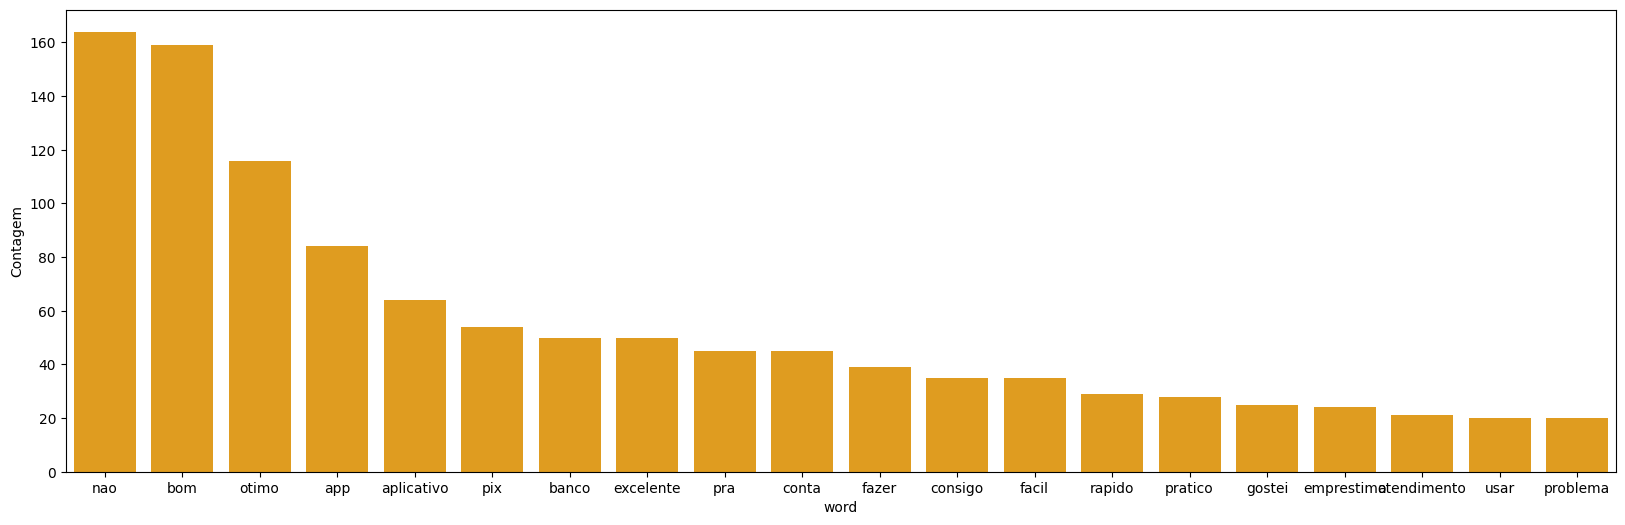

In [73]:
def word_cloud(dataframe, column):

  merged_text = ' '.join(dataframe[column])

  word_cloud = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(merged_text)
  plt.figure(figsize=(10,7))
  plt.imshow(word_cloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()

frequency_graph(df, 'stopWordsUnidecode', 20)

In [74]:
ruim = df[df['category'] == 'Ruim']
boa = df[df['category'] == 'Boa']

boa[boa['stopWordsUnidecode'].str.contains('pix')].shape

(6, 10)

In [75]:
ruim[ruim['stopWordsUnidecode'].str.contains('pix')].shape

(36, 10)

nuvem de palavras pra analise

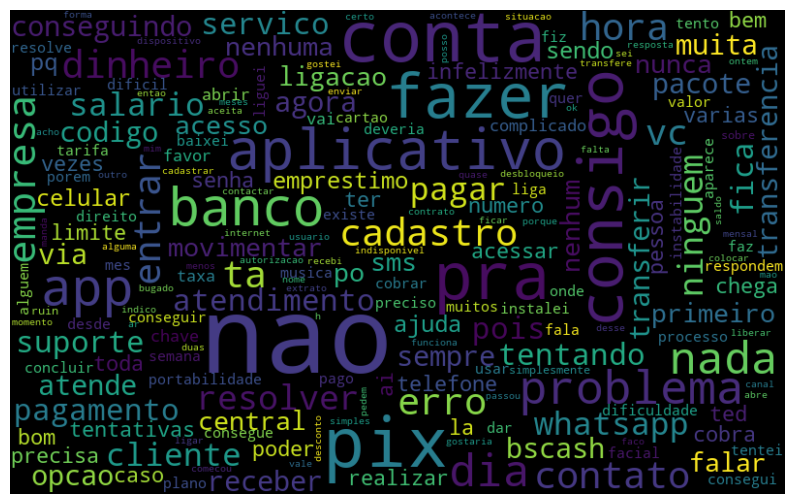

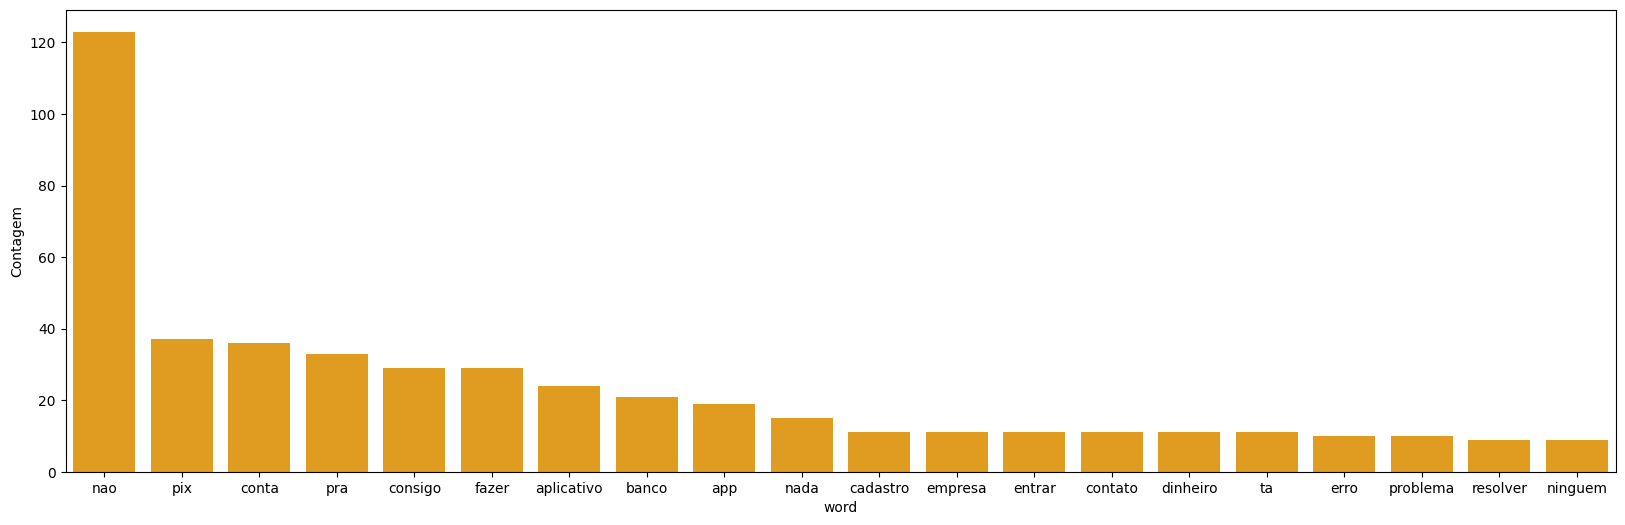

In [76]:
df_category = df[df['category'] ==  'Ruim']
word_cloud(df_category,'stopWordsUnidecode')
frequency_graph(df_category, 'stopWordsUnidecode', 20)


In [77]:
pix = df[df['stopWordsUnidecode'].str.contains("pix|dinheiro|tranferencia|emprestimo")]

pix_category = pix['category'].value_counts().reset_index()

fig = px.pie(pix_category, values='count', names='category',title="Sentimento dos Comentários sobre o Pix (%)",color_discrete_sequence=["#FB8C82", "#FDE47E", "#9FDDA2"])
fig.update_traces(textposition='inside')
fig.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')
fig.show()

In [78]:
atendimento = df[df['Comentário'].str.contains("atendimento|contato|suporte|ligar")]

atendimento_category = atendimento['category'].value_counts().reset_index()

fig = px.pie(atendimento_category, values='count', names='category',title="Sentimento dos Comentários sobre o Atendimento/suporte (%)",color_discrete_sequence=["#FB8C82", "#9FDDA2", "#FDE47E"])
fig.update_traces(textposition='inside')
fig.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')
fig.show()

In [79]:
operacionais = df[df['stopWordsUnidecode'].str.contains("erro|trava|problema|cadastro")]

operacionais_category = operacionais['category'].value_counts().reset_index()

fig = px.pie(operacionais_category, values='count', names='category',title="Sentimento dos Comentários sobre falhas operacionais (%)",color_discrete_sequence=["#FB8C82", "#9FDDA2", "#FDE47E"])
fig.update_traces(textposition='inside')
fig.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')
fig.show()

In [80]:
agrupado = (
    df.groupby(['Versão APP', 'category'])
      .size()
      .reset_index(name='count')
).sort_values('Versão APP')

fig = px.bar(
    agrupado,
    x='Versão APP',
    y='count',
    color='category',
    barmode='group',
    color_discrete_map={
        'Boa': "#58D458",
        'Ruim': "#B44040",
        'Neutro': "#BBAA48"
    }
)

fig.update_layout(
    xaxis_title='Versão do App',
    yaxis_title='Quantidade de Comentários',
    title_x=0.5
)

fig.show()

In [81]:
df['Data'] = pd.to_datetime(df['Data'])

df['Semana'] = df['Data'].dt.to_period('W').apply(lambda r: r.start_time)

group = (
    df.groupby('Semana')['Nota']
      .mean()
      .reset_index()
)

group['media_movel_4s'] = group['Nota'].rolling(4).mean()

media_geral = group['Nota'].mean()

fig = px.line(
    group,
    x='Semana',
    y=['Nota', 'media_movel_4s'],
    title='Evolução da Nota Média Semanal',
    color_discrete_sequence=['orange', 'black']
)

fig.add_hline(y=media_geral, line_dash="dot")


fig.update_xaxes(
    dtick="M1",         
    tickformat="%b %Y"   
)

fig.update_layout(
    yaxis=dict(range=[1,5]),
    title_x=0.5
)

fig.show()

In [82]:
df_category[df_category['Comentário'].str.contains('pix')]['Comentário']

9      o aplicativo da erro várias vezes na hora de r...
12     a empresa trocou meu salário pra essa conta. n...
53                         quase 1 hora para fazer o pix
54     aplicativo atualizou e não abre mais, erro pix...
75     no lugar do nome do banco é para ter meu nome ...
125    app onde precisa contratar e pagar pacotes par...
166    não consegui contato com o banco, você liga el...
173    fica indisponível direto, a pessoa precisar fa...
190    é um tipo de conta corrente pago. não faz pix ...
272    muita, burocracia, para fazer transferências v...
315                     a função de pix muito complicado
321    pra quem não consegue fazer o pix pela chave c...
366    não estou conseguindo realizar as transferênci...
371    muitos erros, especificamente na transferência...
394    a conta não me permite fazer pix, suporte ning...
395                      sempre com instabilidade no pix
396    app falha da erro ainda cobra pra pix..banco q...
406    até agora estou insatisf